# 03 - Análise exploratória (EDA)

Notebook responsável pela análise exploratória dos dados limpos em
`data/processed/`: estatísticas descritivas, correlações entre variáveis
climáticas e produção cafeeira, e geração de gráficos exploratórios
(salvos em `figuras/`).

Usa as funções de `src/risco.py`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
df.shape

(9132, 4)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9132 entries, 0 to 9131
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                9132 non-null   str    
 1   temperature_2m_max  9132 non-null   float64
 2   temperature_2m_min  9132 non-null   float64
 3   precipitation_sum   9132 non-null   float64
dtypes: float64(3), str(1)
memory usage: 374.7 KB


In [3]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2000-01-01,21.5,18.7,37.7
1,2000-01-02,20.0,18.8,33.4
2,2000-01-03,21.3,18.4,44.9
3,2000-01-04,20.7,17.9,13.4
4,2000-01-05,26.4,17.1,1.1


In [4]:
df.tail()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
9127,2024-12-27,22.4,19.1,24.9
9128,2024-12-28,25.7,18.3,12.9
9129,2024-12-29,24.3,17.8,28.7
9130,2024-12-30,26.3,17.4,8.8
9131,2024-12-31,26.4,16.5,6.3


In [5]:
df.describe()

,temperature_2m_max,temperature_2m_min,precipitation_sum
count,9132.000000,9132.000000,9132.000000
mean,25.311947,15.465703,3.203887
std,2.929169,3.141925,6.717872
min,14.300000,3.100000,0.000000
25%,23.400000,13.200000,0.000000
50%,25.500000,16.200000,0.100000
75%,27.300000,18.000000,3.400000
max,36.400000,22.100000,90.600000


## Observações iniciais

1. **Temperatura mínima tem uma cauda fria acentuada**: a média da mínima
   diária é ~15,5 °C (plausível para Lavras, que fica a ~900 m de
   altitude), mas o valor mínimo absoluto é 3,1 °C — indício de eventos
   de geada, relevantes para risco na cafeicultura.
2. **Chuva é muito assimétrica (skewed)**: a mediana de precipitação
   diária é de apenas 0,1 mm, bem abaixo da média de 3,2 mm, e o máximo
   chega a 90,6 mm em um único dia. Isso mostra que a maior parte dos
   dias é seca, com poucos eventos de chuva intensa puxando a média
   para cima — típico do regime de chuvas concentradas em Lavras.

## Índices de risco climático

Usando as funções de `src/risco.py`, calculamos indicadores de risco relevantes para a cafeicultura: dias de geada (leve/severa), dias de chuva excessiva e ocorrências de veranico (sequência de dias secos dentro da estação chuvosa, out-mar).

In [6]:
import sys
sys.path.append("..")

from src.risco import resumo_anual_risco, contar_sequencias_secas

df["time"] = pd.to_datetime(df["time"])

In [7]:
resumo = resumo_anual_risco(df)
resumo

,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
2000,0,0,1,1
2001,0,0,0,1
2002,0,0,1,2
2003,0,0,0,2
2004,0,0,1,0
2005,0,0,0,2
2006,0,0,0,1
2007,0,0,1,3
2008,0,0,2,0


**Nota sobre geada (limitação de fonte, decisão registrada)**: com o limiar de geada leve (≤3°C), nenhum dia da série é classificado — a mínima absoluta observada na base é 3,1°C. Isso é uma limitação da fonte Open-Meteo (dado de modelo/reanálise em grade, não estação terrestre local), que tende a suavizar extremos.

Investigamos a alternativa: existe uma estação convencional real do INMET em Lavras, no campus da UFLA (código 83687, operando desde 1911, coordenadas quase idênticas às usadas aqui). Não há estação automática do INMET na cidade (a mais próxima é Varginha, ~55 km, desde 2006). O acesso à série histórica da estação 83687, porém, é feito exclusivamente pelo BDMEP do INMET, que exige criar conta — decidimos não seguir por esse caminho nesta fase do projeto. Vale registrar também um alerta da própria UFLA (responsável pela estação, em convênio com o INMET): a série de Lavras tem bastante falha de dados mesmo na fonte original.

**Decisão**: mantemos o Open-Meteo como fonte única nesta fase e tratamos a subestimação de geada como uma limitação conhecida e documentada da pesquisa, não como um bug a corrigir agora. Retomar com dados de estação real (BDMEP ou outra rede) fica como possível trabalho futuro.

**Atualização (2026-08-16): tentativa de destravar a via BDMEP/INMET.** Depois da decisão acima, chegamos a criar conta no BDMEP e solicitar a exportação da série da estação 83687 — mas o e-mail com o CSV nunca chegou. Hoje tentamos duas alternativas para não ficar bloqueados esperando essa resposta:

1. Acessar a API pública (`apitempo.inmet.gov.br`) e o portal de dados históricos do INMET diretamente — ambos recusaram a conexão em toda tentativa (reset de conexão / erro 502), então não são uma via viável hoje.
2. Testar se um modelo de reanálise de grade mais fina no próprio Open-Meteo (ERA5-Land, ~9 km, contra o ERA5/`best_match` usado até aqui, ~25-31 km) captura geada que o modelo atual suaviza. Usamos como referência um evento real e bem documentado: a geada histórica de julho/2021 no Sul de Minas.

In [8]:
import requests

params_base = {
    "latitude": -21.24,
    "longitude": -44.99,
    "start_date": "2021-07-15",
    "end_date": "2021-07-31",
    "daily": "temperature_2m_min",
    "timezone": "America/Sao_Paulo",
}

resp_era5 = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params_base)
resp_era5_land = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={**params_base, "models": "era5_land"},
)

comparacao_modelos = pd.DataFrame({
    "data": resp_era5.json()["daily"]["time"],
    "tmin_era5": resp_era5.json()["daily"]["temperature_2m_min"],
    "tmin_era5_land": resp_era5_land.json()["daily"]["temperature_2m_min"],
})
print("Mínima ERA5:", comparacao_modelos["tmin_era5"].min(), "°C")
print("Mínima ERA5-Land:", comparacao_modelos["tmin_era5_land"].min(), "°C")
comparacao_modelos


Mínima ERA5: 3.7 °C
Mínima ERA5-Land: 4.9 °C


,data,tmin_era5,tmin_era5_land
0,2021-07-15,9.7,9.7
1,2021-07-16,11.4,11.2
2,2021-07-17,12.1,11.7
3,2021-07-18,13.6,15.4
4,2021-07-19,8.1,9.0
5,2021-07-20,3.7,6.5
6,2021-07-21,8.0,9.0
7,2021-07-22,10.1,10.4
8,2021-07-23,9.3,9.8
9,2021-07-24,9.1,9.3


**Resultado**: mesmo na janela do evento de geada mais citado da década para o Sul de Minas, nenhum dos dois modelos do Open-Meteo chega a 3°C (mínimas na casa de 3,7-4,9°C) — ou seja, trocar o modelo de reanálise não resolve a limitação. Isso é evidência a favor da hipótese original: o problema é a resolução espacial de qualquer dado em grade frente a um evento de geada, que é muito local (topografia, drenagem de ar frio), não um parâmetro de fonte que dê para ajustar via API.

**Decisão (reafirmada)**: com a via INMET/BDMEP indisponível hoje (sem resposta ao pedido de exportação, API e portal fora do ar para acesso automatizado) e a alternativa de modelo não resolvendo o problema, mantemos o Open-Meteo como fonte única nesta fase e fechamos esta investigação. Acesso a dado de estação real segue como trabalho futuro (ver `docs/relatorio.md`), retomado se/quando a exportação do BDMEP responder.

**Atualização 2 (2026-08-16): conseguimos a estação real, afinal.** Enquanto mapeávamos alternativas ao BDMEP, achamos que o repositório do BR-DWGD (usado no teste do ERA5-Land acima) também disponibiliza, à parte da grade interpolada, os **dados brutos de observação por estação** que foram usados para construir a grade — arquivo leve (`Tmin.npz`, ~113MB, todas as estações do Brasil), sem precisar de conta nem download da grade completa (~7GB). A estação **83687 (Lavras) está nele**, com cobertura de 98,5% no recorte 2000-2024. Coletado em `01_coleta.ipynb` e limpo em `02_limpeza.ipynb` — ver `src/coleta.py::coletar_geada_estacao_83687`.

Isso substitui a fonte de geada (só a de geada — chuva excessiva e veranico continuam com o Open-Meteo, que funciona bem para essas variáveis) sem invalidar a investigação acima: o teste com ERA5-Land seguiu correto em mostrar que **nenhum dado de grade** resolveria isso, e foi justamente essa investigação que nos levou a procurar dado de estação de verdade.

In [9]:
df_geada = pd.read_csv("../data/processed/lavras_geada_estacao_83687_limpo.csv")
df_geada["time"] = pd.to_datetime(df_geada["time"])

df = df.merge(df_geada[["time", "tmin_estacao"]], on="time", how="left")

resumo = resumo_anual_risco(df, tmin_geada=df["tmin_estacao"])
resumo


,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
2000,1,0,1,1
2001,0,0,0,1
2002,0,0,1,2
2003,0,0,0,2
2004,0,0,1,0
2005,0,0,0,2
2006,0,0,0,1
2007,0,0,1,3
2008,0,0,2,0


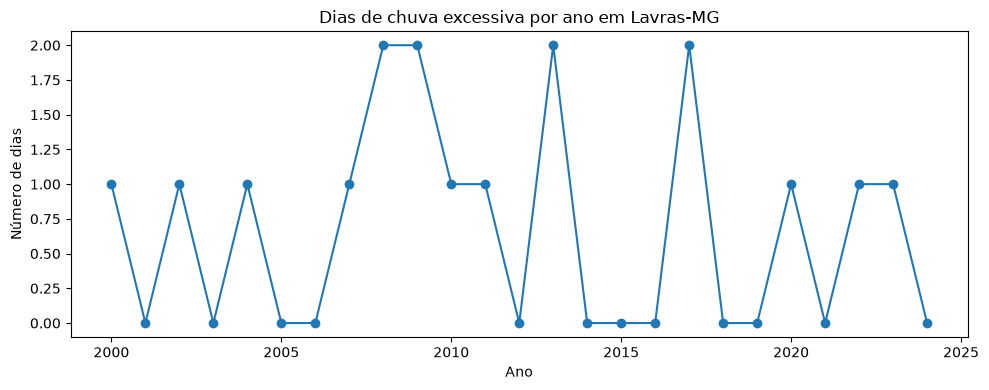

In [10]:
import matplotlib.pyplot as plt

resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.savefig("../figuras/chuva_excessiva_por_ano.png", dpi=150)
plt.show()

### Veranicos

Sequências de pelo menos 10 dias secos consecutivos ocorrendo dentro da estação chuvosa (outubro a março), quando a planta espera chuva regular.

In [11]:
veranicos = contar_sequencias_secas(df)
print("Veranicos detectados:", len(veranicos))
veranicos

Veranicos detectados: 30


,inicio,fim,duracao
0,2000-10-07,2000-10-20,14
1,2001-02-17,2001-03-02,14
2,2002-03-28,2002-04-06,10
3,2002-10-02,2002-10-17,16
4,2003-02-03,2003-02-14,12
5,2003-10-12,2003-10-21,10
6,2005-03-26,2005-04-05,11
7,2005-10-08,2005-10-18,11
8,2006-01-09,2006-01-25,17
9,2007-02-28,2007-03-16,17


## Clima x Produção cafeeira

Pergunta de pesquisa central do projeto: existe correlação histórica entre
os riscos climáticos (geada, chuva excessiva, veranico) e a produtividade
do café em Lavras-MG? Juntamos o resumo anual de risco (`resumo`, acima)
com a série anual de produção do IBGE/SIDRA (`data/processed/lavras_producao_cafe_limpo.csv`)
para investigar.

In [12]:
df_cafe = pd.read_csv("../data/processed/lavras_producao_cafe_limpo.csv")
df_cafe = df_cafe.set_index("ano")

clima_x_producao = resumo.join(df_cafe, how="inner")
clima_x_producao

,geada_leve,geada_severa,chuva_excessiva,veranicos,quantidade_produzida_t,rendimento_medio_kg_ha,area_colhida_ha
ano,,,,,,,
2000,1,0,1,1,7210,2060,3500
2001,0,0,0,1,7560,2160,3500
2002,0,0,1,2,3780,1080,3500
2003,0,0,0,2,3780,1080,3500
2004,0,0,1,0,4440,1200,3700
2005,0,0,0,2,4440,1200,3700
2006,0,0,0,1,4920,1200,4100
2007,0,0,1,3,2952,720,4100
2008,0,0,2,0,3825,900,4250


### Correlação

Usamos correlação de Pearson entre os 4 indicadores de risco climático e
as 3 variáveis de produção. **Ressalva importante**: a série tem apenas
25 anos (um ponto por ano), uma amostra pequena para conclusões causais —
tratamos os resultados como indícios exploratórios, não como prova
estatística robusta.

In [13]:
colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]

corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]
corr_cruzada

,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve,-0.275739,0.193283,0.351341
geada_severa,NaN,NaN,NaN
chuva_excessiva,-0.066706,-0.107639,-0.048883
veranicos,-0.230010,-0.209704,-0.062119


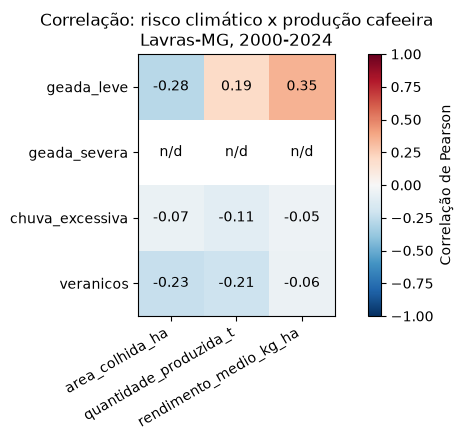

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(corr_cruzada, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas_producao)), labels=colunas_producao, rotation=30, ha="right")
ax.set_yticks(range(len(colunas_risco)), labels=colunas_risco)

for i in range(len(colunas_risco)):
    for j in range(len(colunas_producao)):
        valor = corr_cruzada.iloc[i, j]
        texto = "n/d" if pd.isna(valor) else f"{valor:.2f}"
        ax.text(j, i, texto, ha="center", va="center", color="black")

ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 2000-2024")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.savefig("../figuras/correlacao_risco_producao.png", dpi=150, bbox_inches="tight")
plt.show()

### Leitura dos resultados

- **Geada deixou de ser `n/d`**: com o dado real da estação 83687, o índice
  `geada_leve` passou a ter variação — 1 único dia de geada leve nos 25 anos
  (18/07/2000, 2,0°C), zero em todos os outros anos. `geada_severa` continua
  `n/d`: a mínima absoluta observada no período nunca chegou a 0°C nesta
  estação, então a coluna não tem variância (correlação indefinida).
- **`geada_leve` aparece com as maiores correlações da tabela** (área
  colhida: -0,28; quantidade produzida: +0,19; rendimento médio: +0,35) —
  mas isso **não deve ser lido como "geada aumenta produtividade"**. Com
  apenas 1 ano positivo em 25, a correlação é essencialmente uma
  comparação entre um único ano (2000) e todos os outros — estatisticamente
  frágil demais para indicar tendência. Reforça essa leitura o próprio
  sinal: 2000 teve o 2º maior rendimento da série inteira (2.060 kg/ha),
  o oposto do que a agronomia prevê para geada (que costuma reduzir
  produtividade, não aumentar) — um indício forte de que a correlação é
  coincidência de amostra pequena, não um efeito real.
- **Fora a geada, as correlações continuam fracas** (|r| < 0,25). Veranico
  x área colhida (r ≈ -0,23) segue sendo o indicador mais confiável dos
  quatro, por variar de forma contínua ao longo dos 25 anos em vez de
  depender de um único ano atípico.
- **Cuidado com `area_colhida_ha`**: a série cresce de forma quase
  monotônica ao longo dos 25 anos (3.500 ha em 2000 → 5.020 ha em 2024),
  provavelmente refletindo expansão econômica da cafeicultura na região,
  não um sinal climático. Correlações envolvendo essa coluna podem ser
  espúrias por essa tendência temporal compartilhada.
- **`rendimento_medio_kg_ha`** (produtividade por área, menos afetado
  pela expansão de área) é o proxy mais limpo de produtividade — e, fora
  o resultado frágil de geada acima, é onde as correlações restantes
  ficam mais próximas de zero (chuva excessiva: -0,05; veranico: -0,06).

**Conclusão desta fase**: conseguir dado de estação real resolveu o
problema de *medir* geada (não é mais uma limitação de fonte — ver
`docs/relatorio.md`), mas revelou um problema diferente: nesses 25 anos,
nesta estação, geada foi rara demais (1 ocorrência) para testar
estatisticamente se ela afeta produção. Fora isso, não encontramos
evidência de relação linear forte entre risco climático anual e
produtividade do café em Lavras-MG. Isso não significa que a relação não
exista — pode ser não linear, defasada, ou exigir uma amostra maior/mais
granular do que 25 pontos anuais e mais anos de geada observada. Fica
como direção de trabalho futuro.

### Correlação com defasagem (lag)

A correlação acima compara risco climático e produção do **mesmo ano**.
Mas um evento climático pode só afetar a safra do ano seguinte (ex.:
geada/veranico prejudica a floração, e o efeito na colheita aparece
depois). Aqui deslocamos o risco climático um ano para frente: risco do
ano N x produção do ano N+1.

In [15]:
resumo_defasado = resumo.shift(1)
resumo_defasado.columns = [f"{col}_ano_anterior" for col in resumo_defasado.columns]

clima_x_producao_defasada = resumo_defasado.join(df_cafe, how="inner")

colunas_risco_defasado = [f"{col}_ano_anterior" for col in colunas_risco]
corr_defasada = clima_x_producao_defasada.corr(method="pearson").loc[colunas_risco_defasado, colunas_producao]
corr_defasada

,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve_ano_anterior,-0.299072,0.251146,0.444933
geada_severa_ano_anterior,NaN,NaN,NaN
chuva_excessiva_ano_anterior,0.035454,-0.046689,-0.054415
veranicos_ano_anterior,-0.191431,0.066690,0.171315


### Comparação por faixas (não linear)

Correlação de Pearson só captura relação **linear**. Como alternativa,
separamos os anos em dois grupos pela mediana de veranicos (o indicador
que varia de forma contínua ano a ano com a correlação mais confiável —
geada fica de fora por ter só 1 ano positivo, ver leitura acima) e
comparamos a produção entre eles —
uma relação não linear apareceria aqui mesmo com correlação linear
baixa.

In [16]:
mediana_veranicos = clima_x_producao["veranicos"].median()
faixa = clima_x_producao["veranicos"].ge(mediana_veranicos).map({
    True: f"muitos veranicos (>= {mediana_veranicos:.0f})",
    False: f"poucos veranicos (< {mediana_veranicos:.0f})",
})

comparacao_faixas = clima_x_producao.groupby(faixa)[colunas_producao].agg(["mean", "count"])
comparacao_faixas

area_colhida_ha       quantidade_produzida_t        \
                                   mean count                   mean count   
veranicos                                                                    
muitos veranicos (>= 1)     4218.388889    18            5699.722222    18   
poucos veranicos (< 1)      4280.000000     7            5707.714286     7   

                        rendimento_medio_kg_ha        
                                          mean count  
veranicos                                             
muitos veranicos (>= 1)            1372.888889    18  
poucos veranicos (< 1)             1328.571429     7

### Leitura: defasagem e faixas

- **Defasagem**: `geada_leve_ano_anterior` x rendimento sobe para r ≈ 0,44
  — a maior correlação de toda a análise — mas é o mesmo problema de
  amostra: desloca o único ano de geada (2000) para explicar 2001, que
  por acaso teve o **maior** rendimento de toda a série (2.160 kg/ha).
  Dois anos bons vizinhos a uma única geada leve não é evidência de
  efeito real, é coincidência de amostra pequena — do jeito que estava
  antes de termos dado de estação, não dá para testar isso direito com
  só 1 ocorrência em 25 anos. As demais correlações defasadas continuam
  fracas (|r| < 0,2); veranico do ano anterior x rendimento troca de
  sinal em relação ao mesmo ano (-0,06 → +0,17), mas ambos fracos demais
  para conclusão — mais provável ruído estatístico com n=25 do que
  efeito real de defasagem.
- **Faixas**: anos com muitos veranicos (≥1, mediana) e anos com poucos
  (0) têm produção praticamente igual — rendimento médio 1.373 kg/ha
  vs 1.329 kg/ha, uma diferença de ~3%, bem dentro do que se espera de
  ruído ano a ano. Não há sinal de efeito não linear aqui. (Não repetimos
  essa comparação para geada porque com só 1 ano positivo ela seria
  idêntica à correlação direta acima.)

**Atualização da conclusão**: testamos correlação direta, defasada e
comparação por faixas — em nenhuma abordagem apareceu uma relação clara
e estatisticamente confiável entre os riscos climáticos medidos e a
produtividade do café. A diferença desta rodada é que geada deixou de
ser um problema de *fonte de dado* (resolvido com a estação 83687 real)
e passou a ser um problema de *tamanho de amostra de eventos extremos*
— só 1 geada em 25 anos nesta estação. O resultado mais honesto desta
fase continua sendo: **com os dados e índices atuais, não conseguimos
demonstrar que clima explica a variação de produtividade em
Lavras-MG** — mas agora sabemos exatamente por quê em cada variável, o
que aponta com mais precisão para os próximos passos (mais anos de
geada observada, mais municípios, controle por preço) em vez de uma
resposta definitiva.